This notebook shows a Julia version of the Matlab code of Rylander's textbook for the simulation of a rectangular coaxial cable.

A few things to point out:
 - In general, do not specify the data type of function arguments
 - Use templating to get access to the data type of a passed function argument (e.g., as I do it with the ::F)
   Then, correctly initialize the variables in function body to avoid implicit conversions

In [1]:
"""
    capacitor(a, b, c, d, n, tol, rel)
    
    Computes the capacitance per unit length (pF/m) of a coaxial pair of rectangles where
    dimensions of the inner rectangle are width a and height b, and the dimensions
    of the outer rectangle are width c and height d.

    The parameter `n` is the number of points in x-direction, and the capacitance is
    computed up to a relative tolerance `tol`. The parameter `rel` is the relaxation parameter for
    Gauss-Seidel.
"""
function capacitor(
    a::F, b::F, c::F, d::F, n, 
    tol::F, rel::F; 
    maxiter=1000, verbose=false,
    gauss_strategy="forward"
) where F<:Real
    
    # Note: F is a data type (e.g., Float32, Float64, BigFloat etc)
    # 1) By using this notation, we enforce that all real numbers have
    #    the same data type
    # 2) F is set automatically to the data type of the function arguments
    #    We will later use F to correctly initialize the system matrices
    
    # Make grids
    h = F(0.5)*c/n    # Cell length
    na = Int(round(0.5*a/h)) # Number of segements on 'a' in x-direction  (inner conductor)
    m = Int(round(0.5*d/h)) # Number of segments on 'd' in y-direction  (outer conductor)
    mb = Int(round(0.5*b/h)) # Number of segments on 'b' in y-direction  (inner conductor)
    
    # Initialize potential and mask array
    # 2D array of zeros with element type F and size (n+1, m+1).
    f = zeros(F, n+1, m+1) # 2D-array with solution # NOTE +1 for the boundary
    mask = ones(n+1, m+1)*rel   # 2d-array with relaxation 
                                # mask[i,j] = 0 implies unchanged f[i,j]
    
    # Set boundary values
    for i = 1:na+1 # na+1 to get the boundary point
        for j = 1:mb+1
            mask[i, j] = F(0.0) # Potential on inner conductor is known, must not change!
            f[i, j]    = F(1.0)
        end
    end
    
    # Iteration
    oldcap = F(0.0)
    cap = F(0.0)
    for iter = 1:maxiter
        seidel!(f, mask, n, m)
        cap = gauss(f, n, m, gauss_strategy=gauss_strategy) # gauss refers here to Gauss's law to compute the charge
        if abs(cap - oldcap)/cap < tol
            if verbose
                println("Converged in " * string(iter) * " iterations")
            end
            return cap, f, h, iter
        else
            oldcap = cap
        end
    end
    println("Did not converged in " * string(maxiter) * " iterations")
    
    # Return what we have
    return cap, f, h, maxiter
end

# Use the exclamation to denote that we modify one of the arguments
function seidel!(f::Matrix{F}, mask, n, m) where F
    
    for i = 2:n # Cases i=1 and j=1 need to be treated separately
        for j = 2:m
            f[i, j] = f[i, j] + mask[i, j]*(F(0.25)*(f[i-1, j] + f[i+1, j] + f[i, j-1] + f[i, j+1]) - f[i, j])
        end
    end
    
    # Symmetry on left boundary i-1 -> i+1
    i = 1;
    for j = 2:m
        f[i, j] = f[i, j] + mask[i,j]*(F(0.25)*(f[i+1, j] + f[i+1, j] + f[i, j-1] + f[i, j+1]) - f[i, j])
    end
    
    # Symmetry on lower boundary j-1 -> j+1
    j=1
    for i = 2:n
        f[i, j] = f[i, j] + mask[i,j]*(F(0.25)*(f[i-1, j] + f[i+1, j] + f[i, j+1] + f[i, j+1]) - f[i, j])
    end
    
end


function gauss(f::Matrix{F}, n, m; gauss_strategy=gauss_strategy) where F
   
    q = F(0)
    
    if gauss_strategy == "forward"
        # Use a forward difference to form the -∇ and use that
        # f[i,m+1] = 0V on the upper boundary and f[n+1,j] = 0V
        # on the right boundary
        
        # Use trapezoid rule for integration on each cell

        for i = 1:(n-1) 
            q += (f[i, m] + f[i+1, m])*F(0.5)
        end

        for j = 1:(m-1)
            q += (f[n, j] + f[n, j+1])*F(0.5)
        end

    elseif gauss_strategy == "centered"
        # Use a central difference to form the -∇ and use that
        # f[i,m+1] = 0V on the upper boundary and f[n+1,j] = 0V
        # on the right boundary
        
        # Use trapezoid rule for integration on each cell

        for i = 1:(n-1)
            q += (f[i, m-1] + f[i+1, m-1])*F(0.25)
        end

        for j = 1:(m-1)
            q += (f[n-1, j] + f[n-1, j+1])*F(0.25) # integrate along right boundary
        end

    elseif gauss_strategy == "staggered"
        # Use a staggered difference to form the -∇ and use that
        # f[i,m+1] = 0V on the upper boundary and f[n+1,j] = 0V
        # on the right boundary
        
        # Note that with the staggered difference, we need to pay
        # special attention to the corner cell
        # where we integrate only to the middle point
        # Do obtain a value for -∇, we use linear interpolation
        
        # Use trapezoid rule for integration on each cell

        for i = 1:(n-1) 
            q += (f[i, m] + f[i+1, m])*F(0.5)
        end
    
        # I am interpolating the potential value
        # Of course, f[n+1, m] is zero, too
        q += (f[n, m] + F(0.5)*(f[n, m] + f[n+1, m]))*F(0.25)

        for j = 1:(m-1)
            q += (f[n, j] + f[n, j+1])*F(0.5)
        end
        
        q += (f[n, m] + F(0.5)*(f[n, m] + f[n, m+1]))*F(0.25)
    end

    cap = q*4 # 4 quadrants
    return cap*F(8.854187) # ε_0 * 1e12 gives answer in pF/m

end

gauss (generic function with 1 method)

## Help

We provided a docstring to document the capacitor function. The documentation can be displayed by putting a question mark in front of it. You can do this also with other Julia functions to get a quick help.

In [2]:
?capacitor

search: capacitor



```
capacitor(a, b, c, d, n, tol, rel)

Computes the capacitance per unit length (pF/m) of a coaxial pair of rectangles where
dimensions of the inner rectangle are width a and height b, and the dimensions
of the outer rectangle are width c and height d.

The parameter `n` is the number of points in x-direction, and the capacitance is
computed up to a relative tolerance `tol`. The parameter `rel` is the relaxation parameter for
Gauss-Seidel.
```


## Setup of experiment
We define in a single place the key parameters, we do not wish to change.

In [3]:
# setup dimensions
a = 0.01
b = a
c = 0.02
d = c
dims = (a, b, c, d)

# Solver parameters
tol = 1e-9
rel = 1.9

cap, f, h = capacitor(dims..., 120, tol, rel, maxiter=10000)

(90.65813122420914, [1.0 1.0 … 0.016085663543143548 0.0; 1.0 1.0 … 0.016084927635743124 0.0; … ; 0.016085663543143735 0.016084927635743193 … 0.00021826119212580843 0.0; 0.0 0.0 … 0.0 0.0], 8.333333333333333e-5, 629)

## Visualization of the Potential
Let's visualize using a heatmap. One of the advantages of a finite-difference approach, when solved on the matrix itself, is how simple the visualization is.

There are many packages in Julia for plotting. Some are wrappers for established plotting tools from other languages (e.g., `PyPlot.jl` package). The package `Plots.jl` is a meta-package. It provides a unified interface and let's one choose a backend (such as PyPlot or TikZ).

When possible, I try to use this package due to its flexibility.

A downside is that it does not support all the features that other packages might have.

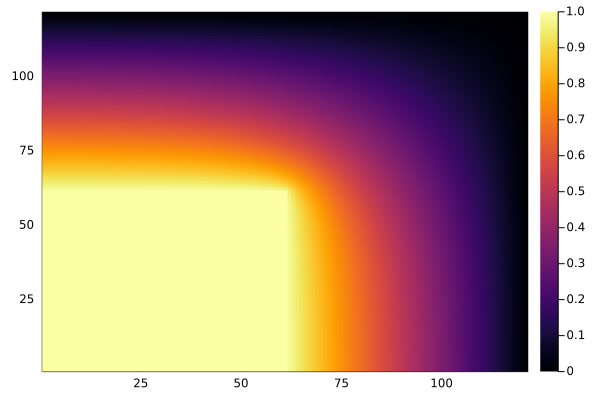

In [4]:
using Plots
heatmap(f)

Let's see if it makes if difference how we compute the gradient of the potential. Since we want to do a convergence analysis, and in particular, estimate the order of convergence, we should bear in mind the requirement
\begin{equation}
    h_{i}/h_{i+1} = h_{i+1}/h_{i+2}
\end{equation}
By doubling the number of segments in `nvals`, I achieve exactly this.

In [5]:
nvals = [5; 10; 20; 40; 80; 160; 320]

caps_forward = typeof(a)[]
caps_centered = typeof(a)[]
caps_staggered = typeof(a)[]
iters_forward = Int64[]
iters_centered = Int64[]
iters_staggered = Int64[]
hs = typeof(a)[]

for n in nvals
    cap_forward, ~, h, iter_forward     = capacitor(dims..., n, tol, rel, maxiter=50000, gauss_strategy="forward")
    cap_centered, ~, ~, iter_centered   = capacitor(dims..., n, tol, rel, maxiter=50000, gauss_strategy="centered")
    cap_staggered, ~, ~, iter_staggered = capacitor(dims..., n, tol, rel, maxiter=50000, gauss_strategy="staggered")

    push!(caps_forward, cap_forward)
    push!(caps_centered, cap_centered)
    push!(caps_staggered, cap_staggered)
    
    push!(iters_forward, iter_forward)
    push!(iters_centered, iter_centered)
    push!(iters_staggered, iter_staggered)
    
    push!(hs, h)
end  

Next, I want to print out the results in a tabular form. For this, I utilize the package formatting. It works similar to `printf` from C.

In [6]:
using Formatting

zipped_input = zip(nvals, hs, caps_forward, iters_forward, caps_centered, iters_centered, caps_staggered, iters_staggered)

for (n, h, cap_forward, iter_forward, cap_centered, iter_centered, cap_staggered, iter_staggered) in zipped_input
    printfmtln(
        "{1:<6d} {2:<10.6f} {3:<6d} {4:<14.10f} {5:<6d} {6:<14.10f} {7:<6d} {8:<14.10f}", 
        n, 
        h, 
        iter_forward,
        cap_forward,
        iter_centered,
        cap_centered,
        iter_staggered,
        cap_staggered        
    )
end

5      0.002000   188    66.7724818160  179    69.9847375081  188    69.1816736349 
10     0.001000   135    90.9580291343  158    92.0971621122  163    91.8123690690 
20     0.000500   159    90.9075632607  160    91.1884999938  162    91.1182601608 
40     0.000250   152    90.7693203452  161    90.8391281377  170    90.8216731434 
80     0.000125   185    90.6855306962  185    90.7029364360  185    90.6985850305 
160    0.000062   1162   90.6451062156  1162   90.6494528836  1162   90.6483662470 
320    0.000031   4560   90.6272588308  4561   90.6283450748  4560   90.6280734765 


## Convergence study

It seems that the forward difference delivers the best performance. Let see, how this pans out for the order of convergence. But first a plot to see what is going on.

In order that we can estimate the order of convergence, it is imperative that the computed capacitance is not oscillating. A plot can quickly reveal this.

### How to make a good plot
Always
 - use markers and different markershapes to visualize how many discretize data points we have
 - also use different line styles. In particular, this is needed when people print black and white (articles in printed journals are typically black and white since authors do not want to pay the extra charge for colored pages
 - always label your axes!!

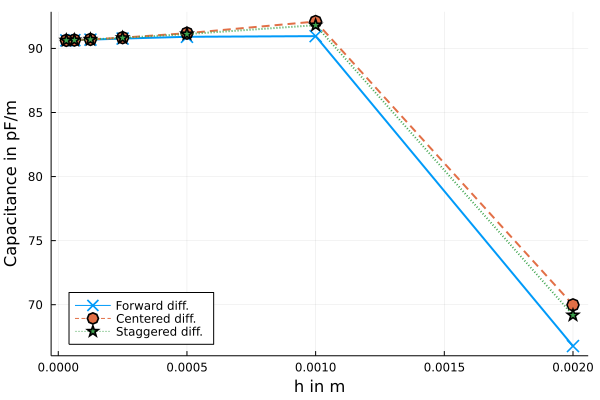

In [14]:
# Put common keyword arguments in a dictionary. 
#If you know Python, you probably have seen the kwargs-technique before
kwargs = Dict(:markersize=>6, :linewidth=>2, :markerstrokewidth=>2)

# General configuration of the plot
plt = plot(xlabel="h in m", ylabel="Capacitance in pF/m", legend=:bottomleft)

plot!(plt, hs, caps_forward, label="Forward diff.", markershape=:x, linestyle=:solid; kwargs...)
plot!(plt, hs, caps_centered, label="Centered diff.", markershape=:o, linestyle=:dash; kwargs...)
plot!(plt, hs, caps_staggered, label="Staggered diff.", markershape=:s, linestyle=:dot; kwargs...)

### Analysis of the plot
 - Common from the large h (i.e., the right side of the x-axes), the capacitance first increases and then decreases
     - This oscillatory behavior can be attributed to a too coarse discretization, but we need to analyse further what is going on
     - Potentially, we are relaxing too much so that we are converging to an unphysical solution
 - For small h, we seem to converge. Lets zoom in to have a better look

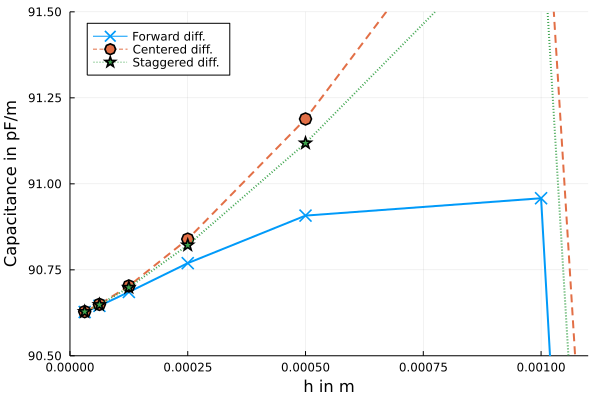

In [15]:
# General configuration of the plot
plt = plot(xlabel="h in m", ylabel="Capacitance in pF/m", legend=:topleft, ylims=(90.5, 91.5), xlims=(0,0.0011))

plot!(plt, hs, caps_forward, label="Forward diff.", markershape=:x, linestyle=:solid; kwargs...)
plot!(plt, hs, caps_centered, label="Centered diff.", markershape=:o, linestyle=:dash; kwargs...)
plot!(plt, hs, caps_staggered, label="Staggered diff.", markershape=:s, linestyle=:dot; kwargs...)

Some more conclusions:
 - The plot indicates convergence. We seem to approach the final capacitance from above.
 - For fitting, we should use only use the last datapoints, where the function is least oscillatory.

### Order of convergence
First, we assess the order of convergence. To this end, we use the formula from the text book.

We use the package `Polynomials.jl` to fit the error

In [16]:
using Polynomials

function estimate_p(h, I)
    return log((I[end-2] - I[end-1])/(I[end-1] - I[end]))/log(h[end-2]/h[end-1])
end

p_forward   = estimate_p(hs, caps_forward)
p_centered  = estimate_p(hs, caps_centered)
p_staggered = estimate_p(hs, caps_staggered)

printfmtln("Order of convergence (forward diff.): {1:<1.3f}", p_forward)
printfmtln("Order of convergence (centered diff.): {1:<1.3f}", p_centered)
printfmtln("Order of convergence (staggered diff.): {1:<1.3f}", p_staggered)

Order of convergence (forward diff.): 1.180
Order of convergence (centered diff.): 1.341
Order of convergence (staggered diff.): 1.307


The results are extremely interesting:
 - Even though forward diff. delivers the best results, it seems that eventually centered and staggered grid difference will yield better results
 - This is not entirely suprising, since forward difference is only $\mathcal O(h)$, while the other two are $\mathcal O(h^2)$
 - In general, our second-order finite-difference approach should have yielded $\mathcal O(h^2)$ convergences when combined with centered or staggered grid computation of the gradient. Why is it not the case? The reason is that the geometry is not smooth enough, i.e., our geometry has corners, thus the function describing the geometry is only $C^ 0$ (continous, but not differentiable at the corner). Thus the assumptions we used to derive the $\mathcal O(h^2)$ are violated.
 - In fact, while the potential is a continuous function, we know that its gradient, the electric field, can become infinity at single points
 - We will analyze this analytically in chapter 7, when we discuss a 2D-wedge.
 - Overall, this limits convergences to around $\mathcal O(h^{1.3x})$
 - **Warning:** Do not jump to the preliminary conclusion that centered difference is in general better than staggered grid difference! The results must, in any case, be taken with a grain of salt and we would need to investigate more carefully why centered difference is in this specific example superior to the staggered grid difference.
 
 ### Fitting
 From the plot, it is clear that we should only consider the capacitances where `h` is small. Otherwise, we include the oscillating behavior at the beginning.
 
 Note that when you use $n$ datapoints, you can fit an $n+1$ order polynomial. In this case, I use the last four data points, and fit a 5th order polynomial

In [17]:
pfit_forward   = fit(hs[end-3:end].^p_forward, caps_forward[end-3:end], 5) # With the claim of the textbook
pfit_centered  = fit(hs[end-3:end].^p_centered, caps_centered[end-3:end], 5) # With the claim of the textbook
pfit_staggered = fit(hs[end-3:end].^p_staggered, caps_staggered[end-3:end], 5) # With the claim of the textbook

Polynomial(90.61423431951285 + 10719.427172129228*x - 5.58346288556964e6*x^2 - 160.3923415179178*x^3 - 0.0035494693033215246*x^4 - 7.267394741246354e-8*x^5)

### Extrapolation to zero
We extrapolate to zero, by considering evaluating the fitted polynomials for $h=0$.

In [18]:
printfmtln("Extrapolation to zero (forward diff.): {1:<1.4f} pF/m", pfit_forward(0))
printfmtln("Extrapolation to zero (centered diff.): {1:<1.4f} pF/m", pfit_centered(0))
printfmtln("Extrapolation to zero (staggered diff.): {1:<1.4f} pF/m", pfit_staggered(0))

Extrapolation to zero (forward diff.): 90.6133 pF/m
Extrapolation to zero (centered diff.): 90.6146 pF/m
Extrapolation to zero (staggered diff.): 90.6142 pF/m


The extrapolated values suggest that the capacitance will be between 90.613 pF/m and 90.6146 pF/m. We probably would need to acquire more datapoints to get more reliable extrapolation.

## Excerise
Study the convergences plot for the case that $a = b = 0.0085$. How would you explain the jump visible in the plot?

Hint: Try to locate the boundary of the inner conductor on your grid.